In [1]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph.message import add_messages
from typing import Optional, TypedDict, Annotated

C:\Users\ankit\AppData\Local\Temp\ipykernel_20448\1610577545.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [15]:
load_dotenv()

python-dotenv could not parse statement starting at line 8


True

In [16]:
llm = ChatGoogleGenerativeAI(model="gemini-flash-3.5-lite")

In [17]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-2-preview", 
    output_dimensionality=768
)

In [18]:
docs= (PyPDFLoader("./research-paper/doc.pdf").load())

In [19]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=400, chunk_overlap=120).split_documents(docs)

In [20]:
vectorstore = FAISS.from_documents(chunks, embeddings)

GoogleGenerativeAIError: Error embedding content (UNAUTHENTICATED): 401 UNAUTHENTICATED. {'error': {'code': 401, 'message': 'Request had invalid authentication credentials. Expected OAuth 2 access token, login cookie or other valid authentication credential. See https://developers.google.com/identity/sign-in/web/devconsole-project.', 'status': 'UNAUTHENTICATED', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'ACCESS_TOKEN_TYPE_UNSUPPORTED', 'metadata': {'method': 'google.ai.generativelanguage.v1beta.GenerativeService.BatchEmbedContents', 'service': 'generativelanguage.googleapis.com'}}]}}

In [21]:
class State(TypedDict):
    query: str
    needs_retrieval: Annotated[bool, "Whether the query needs retrieval or not."]

    docs: list[Document]

    answer: str

In [13]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

NameError: name 'vectorstore' is not defined

In [23]:
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage

class RetrieveDecision(BaseModel):
    needs_retrieval: bool = Field(..., description="Whether the query needs retrieval or not.")

retrieval_decision_prompt = """You decide whether the query needs retrieval or not. 
If the query is related to the research paper, you should set needs_retrieval to True, Something
not in parametric Knowledge of LLM, and only present in the Research Paper. 
Otherwise, set it to False.
"""

retrieval_decider = llm.with_structured_output(RetrieveDecision)
def retrieval_decision_node(state:State):
    response = retrieval_decider.invoke([SystemMessage(content=retrieval_decision_prompt), HumanMessage(content=state["query"])])
    return {"needs_retrieval": response.needs_retrieval}


In [24]:
direct_answer_prompt = ChatPromptTemplate.from_messages([
    ("system" , 
     """
Answer the question based on your parametric knowledge. If you don't know the answer, say "I don't know".
Do NOT assume access to external sources or the research paper. Only use your own knowledge to answer the question.
"""),
("human" , "{query}")])

In [25]:
def direct_answer_node(state:State):
    prompt = direct_answer_prompt.format_prompt(query=state["query"])
    response = llm.invoke(prompt)
    return {"answer": response.content}

In [ ]:
def retrieval_node(state:State):
    docs = retriever.invoke(state["query"])
    return {"docs": docs}

In [ ]:
def route_after_retrieval_decision(state:State):
    if state["needs_retrieval"]:
        return "retrieval_node"
    else:
        return "direct_answer_node"

In [28]:
g = StateGraph(State)
#add nodes
g.add_node("retrieval_decision_node", retrieval_decision_node)
g.add_node("retrieval_node", retrieval_node)
g.add_node("direct_answer_node", direct_answer_node)

In [30]:
#add edges
g.add_edge(START, "retrieval_decision_node")
g.add_conditional_edges("retrieval_decision_node", route_after_retrieval_decision)
g.add_edge("direct_answer_node", END)
g.add_edge("retrieval_node", END)

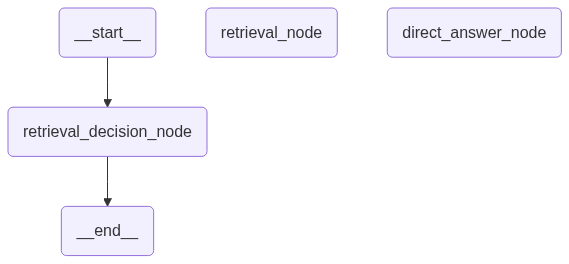

In [31]:
workflow = g.compile()
workflow